<a href="https://colab.research.google.com/github/Rajnandani-tech/Rajnandani-/blob/main/Student_Performance_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Libraries Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


2. Dataset Loading

In [3]:
import zipfile
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

zip_path = "student.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("student_data")

df = pd.read_csv(
    "student_data/student-mat.csv",
    sep=";"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


3. Data Understanding

df.head()

df.tail()

print("Rows and Columns:", df.shape)

print("Column Names:")
print(df.columns.tolist())

df.info()

4. Missing Values

In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


5. Duplicate Values

In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


6. Data Cleaning

In [6]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (395, 33)


7. Basic Statistics

In [7]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:
print("Average G1 Score:", round(df["G1"].mean(), 2))
print("Average G2 Score:", round(df["G2"].mean(), 2))
print("Average Final Score:", round(df["G3"].mean(), 2))

Average G1 Score: 10.91
Average G2 Score: 10.71
Average Final Score: 10.42


8. Gender-wise Analysis

In [9]:
gender_performance = df.groupby("sex")["G3"].mean()

print("Average Final Score by Gender:")
print(gender_performance)

Average Final Score by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


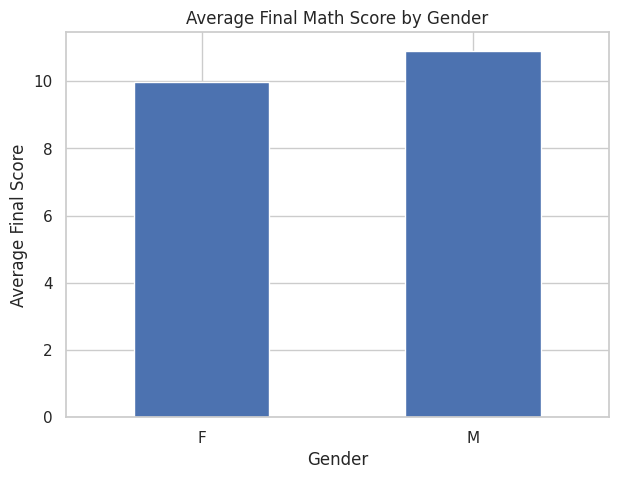

In [10]:
gender_performance.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Final Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Score")
plt.xticks(rotation=0)
plt.show()

9. Study Time vs Final Score

In [11]:
study_time_analysis = df.groupby("studytime")["G3"].mean()

print("Average Final Score by Study Time:")
print(study_time_analysis)

Average Final Score by Study Time:
studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64


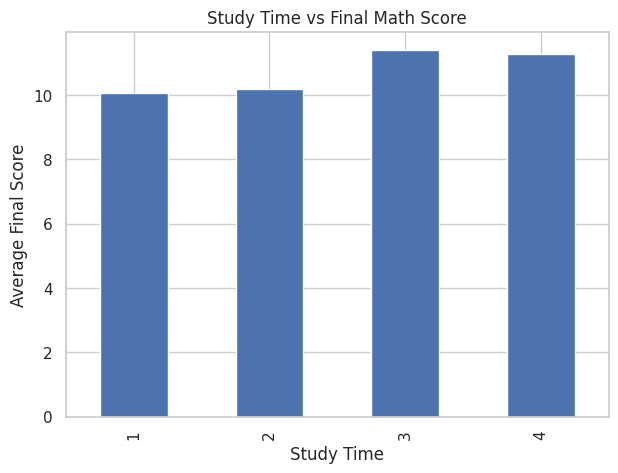

In [12]:
study_time_analysis.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Study Time vs Final Math Score")
plt.xlabel("Study Time")
plt.ylabel("Average Final Score")
plt.show()

10. Final Marks Distribution

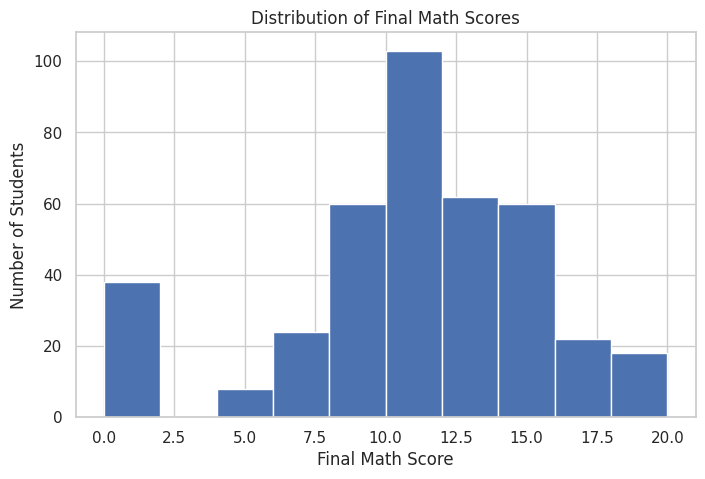

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["G3"], bins=10)

plt.title("Distribution of Final Math Scores")
plt.xlabel("Final Math Score")
plt.ylabel("Number of Students")

plt.show()

11. Previous Marks vs Final Marks

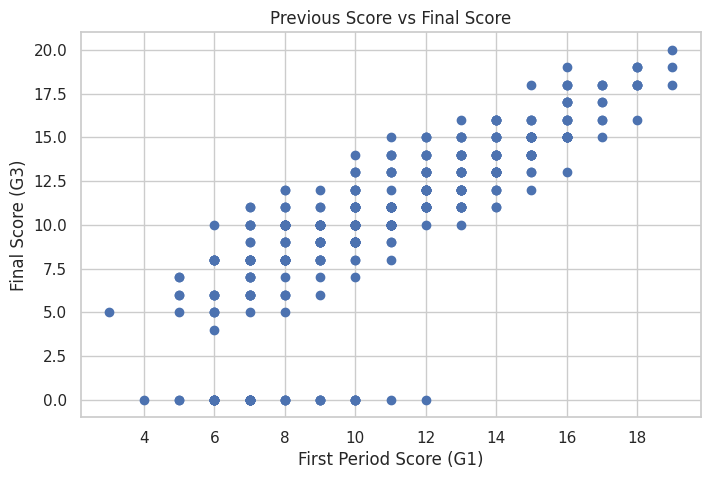

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(df["G1"], df["G3"])

plt.title("Previous Score vs Final Score")
plt.xlabel("First Period Score (G1)")
plt.ylabel("Final Score (G3)")

plt.show()

12. Correlation Analysis

In [15]:
correlation = df[
    ["G1", "G2", "G3", "studytime", "absences"]
].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                 G1        G2        G3  studytime  absences
G1         1.000000  0.852118  0.801468   0.160612 -0.031003
G2         0.852118  1.000000  0.904868   0.135880 -0.031777
G3         0.801468  0.904868  1.000000   0.097820  0.034247
studytime  0.160612  0.135880  0.097820   1.000000 -0.062700
absences  -0.031003 -0.031777  0.034247  -0.062700  1.000000


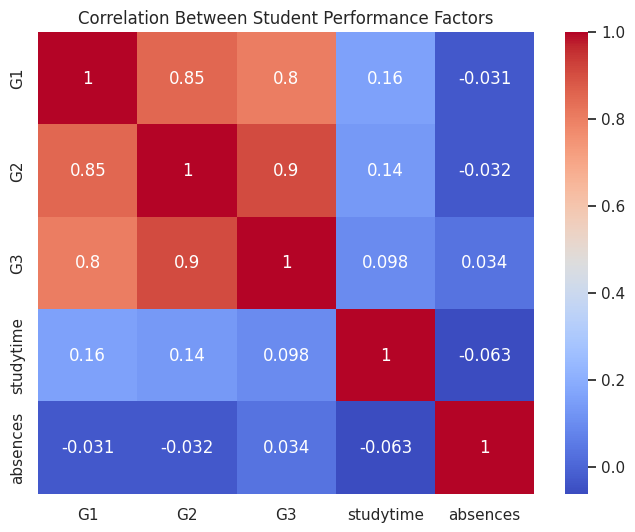

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Student Performance Factors")
plt.show()

13. Top Performing Students

In [17]:
top_students = df.sort_values(
    by="G3",
    ascending=False
).head(10)

print("Top 10 Performing Students:")
print(
    top_students[
        ["school", "sex", "G1", "G2", "G3"]
    ]
)

Top 10 Performing Students:
    school sex  G1  G2  G3
47      GP   M  19  19  20
286     GP   F  18  18  19
374     MS   F  19  18  19
110     GP   M  18  19  19
8       GP   M  16  18  19
113     GP   M  18  19  19
91      GP   F  16  17  18
42      GP   M  19  18  18
36      GP   M  15  16  18
104     GP   M  16  18  18


14. Observations

1. The dataset contains information about student performance.

2. The average final mathematics score gives an overall idea of student performance.

3. Previous scores G1 and G2 show a relationship with the final score G3.

4. Students with different study-time levels show differences in their average final scores.

5. The graphs make it easier to understand patterns in student performance.

6. Previous academic performance is an important factor related to the final score.

15. Conclusion

This project analysed student performance using Python.

The dataset was loaded, understood and cleaned before performing the analysis.

Basic statistics and different visualizations were used to understand student performance.

The analysis shows that previous academic performance is related to the final score.

Overall, this project helped me understand the basic Data Analysis process using Python, Pandas, NumPy, Matplotlib and Seaborn.